# STI_Image construction from Python image files

This notebook shows the recommended STIPy image import path. `from stipy import *` exports `STI_Image` instead of `Image`, so it can be used alongside Pillow's `Image` symbol without a name clash.

In [1]:
from pathlib import Path
import base64

from stipy import *


example_path = Path("sti_image_example.png")
example_png = (
    "iVBORw0KGgoAAAANSUhEUgAAAAEAAAABCAQAAAC1HAwCAAAAC0lEQVR42mP8/x8AAwMCAO+/p9sAAAAASUVORK5CYII="
)
example_path.write_bytes(base64.b64decode(example_png))

"Image" in globals(), "STI_Image" in globals(), example_path

(False, True, PosixPath('sti_image_example.png'))

`STI_Image.from_file()` reads the file bytes directly. Pillow is not required; pass width and height when Pillow is unavailable or when the payload is a raw image format.

In [2]:
sti_image = STI_Image.from_file(example_path, width=1, height=1)
value = MixedValue(sti_image)

sti_image, value.getType(), value.getImage()

(<Image | 1x1 | 68 bytes>, <MixedValueType.Image: 9>, <Image | 1x1 | 68 bytes>)

In [3]:
assert value.getType() == MixedValueType.Image
assert sti_image.getData().getBytes() == example_path.read_bytes()

sti_image.save("sti_image_roundtrip.png")

True

If Pillow is installed, a `PIL.Image.Image` can also be converted explicitly with `from_pil()`, or directly with `STI_Image(pil_image)`.

In [4]:
try:
    from PIL import Image
except ImportError:
    print("Install Pillow to run the PIL conversion example.")
else:
    pil_image = Image.open(example_path)
    from_method = STI_Image.from_pil(pil_image)
    from_constructor = STI_Image(pil_image)
    display(pil_image)
    from_method, from_constructor

For a Python-only display prototype, convert the encoded `BinaryData` payload back into a `PIL.Image` with `BytesIO`. This works for `STI_Image` objects created from encoded formats such as PNG, TIFF, or JPEG. Raw pixel buffers need separate mode/shape handling.

In [ ]:
def sti_image_to_pil(image):
    import io
    from pathlib import Path
    from PIL import Image as PILImage

    data = image.getData() if image.hasData() else None
    if data is not None:
        data.pull()
        payload = data.getBytes()
        if payload is None:
            raise ValueError("STI_Image BinaryData has no readable bytes")

        pil = PILImage.open(io.BytesIO(payload))
        pil.load()
        return pil

    preview_path = Path("sti_image_preview_payload")
    if image.save(str(preview_path)):
        pil = PILImage.open(preview_path)
        pil.load()
        return pil

    raise ValueError("STI_Image has neither readable BinaryData nor a saveable file payload")


try:
    preview_source = globals().get("from_method", sti_image)
    preview_image = sti_image_to_pil(preview_source)
except ImportError:
    print("Install Pillow to display an STI_Image as a PIL image.")
else:
    display(preview_image)
    preview_image

In [6]:
pil_image = Image.open("/home/hogan/code/dev/sti3/examples/python/readWrite/readWrite-random-image-4.png")
from_method = STI_Image.from_pil(pil_image)

In [11]:
preview_image = sti_image_to_pil(from_method)

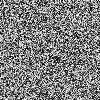

In [12]:
preview_image